In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="../data",
    train=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="../data",
    train=False,
    transform=transform
)

train_iter = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_iter = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [3]:
X,y=next(iter(train_iter))
X.shape,y.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

将展平每个图像，将他们视为长度为784的向量。因为我们的数据集有10个类别，所以网络输出维度为10

In [5]:
num_inputs=784#28*28=784,784个像素块
num_outputs=10
W=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)#W(784,10),根据矩阵乘法,若X为（256，28*28=784），就能进行矩阵乘法
b=torch.zeros(num_outputs,requires_grad=True)

实现softmax

In [6]:
def softmax(X):
    X_exp=torch.exp(X)
    partition=X_exp.sum(1,keepdim=True)#沿着行求和
    return X_exp/partition

我们将每个元素变成一个非负数。此外，依据概率原理，每行总和为1

In [7]:
X=torch.normal(0,1,(2,5))
X_prob=softmax(X)
X_prob,X_prob.sum(1)

(tensor([[0.0269, 0.4528, 0.0237, 0.4389, 0.0577],
         [0.2342, 0.1115, 0.1844, 0.3451, 0.1248]]),
 tensor([1.0000, 1.0000]))

实现softmax回归模型

In [9]:
def net(X):
    return softmax(torch.matmul(X.reshape(-1,W.shape[0]),W)+b)#b的shape：（10，），通过广播机制传播
    #最后得到（256，10）每一行就是每张图片对10个类别的预测概率

实现交叉熵损失函数

In [10]:
def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)),y])#-log是一种损失模型

将预测类别与真实y元素进行比较

In [11]:
def accuracy(y_hat,y):
    """计算预测正确的数量"""
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1)
    cmp=y_hat.type(y.dtype)==y#将y_hat和y的比较结果赋值给cmp
    return float(cmp.type(y.dtype).sum())#将布尔类型cmp转换为int，累加的结果就是正确预测的个数
    

我们可以评估在任意模型net的正确率

In [13]:
def evaluate_accuracy(net,data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net,torch.nn.Module):#判断net是不是pytorch中的神经网络模块
        net.eval()#切换评估模式
    metric=Accumulator(2)
    for X,y in data_iter:
        metric.add(accuracy(net(X),y),y.numel())#前为正确预测数，后为总数
    return metric[0]/metric[1]


Accumulator实例中创建了两个变量，用于分别存储正确预测的数量和预测的总数量

In [14]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self,n):
        self.data=[0.0]*n
    def add(self,*args):#*arg表示可以传入任意数量的位置参数，并把他们收集成一个元组，这可以让add（）很灵活
        self.data=[a+float(b) for a,b in zip(self.data,args)]#将data与args一一对应并相加
    def reset(self):
        self.data=[0.0]*len(self.data)#数据清零
    def __getitem__(self,idx):
        return self.data[idx]

evaluate_accuracy(net,test_iter)#随机出来的模型

0.0823

Softmax回归的训练

In [15]:
def train_epoch_ch3(net,train_iter,loss,updater):
    if isinstance(net,torch.nn.Module):
        net.train()
    metric=Accumulator(3)
    for X,y in train_iter:
        y_hat=net(X)
        l=loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()#梯度清零
            l.backward()
            updater.step()
            metric.add(float(l)*len(y),accuracy(y_hat,y),y.size().numel())
        else:
            l.sum().backward()
            updater(X.shape[0])
            metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())
    return metric[0]/metric[2],metric[1]/metric[2]

定义一个在动画中绘制数据的实用程序类

In [16]:
import matplotlib.pyplot as plt


class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None,
                 xlim=None, ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'),
                 nrows=1, ncols=1, figsize=(3.5, 2.5)):

        if legend is None:
            legend = []

        # 创建画布和子图
        self.fig, self.axes = plt.subplots(
            nrows, ncols, figsize=figsize
        )

        # 如果只有一个子图，也把它变成列表
        if nrows * ncols == 1:
            self.axes = [self.axes]

        # 设置坐标轴
        self.config_axes = lambda: self.set_axes(
            xlabel, ylabel, xlim, ylim,
            xscale, yscale, legend
        )

        # 保存数据
        self.X, self.Y, self.fmts = None, None, fmts

    def set_axes(self, xlabel, ylabel, xlim, ylim,
                 xscale, yscale, legend):

        ax = self.axes[0]

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_xscale(xscale)
        ax.set_yscale(yscale)

        if legend:
            ax.legend(legend)

        ax.grid()

    def add(self, x, y):

        # 如果 y 不是列表，就把它变成列表
        if not hasattr(y, '__len__'):
            y = [y]

        # y 中有几个数据，就画几条线
        n = len(y)

        # 第一次调用
        if self.X is None:
            self.X = [[] for _ in range(n)]
            self.Y = [[] for _ in range(n)]

        # 保存数据
        for i in range(n):
            self.X[i].append(x)
            self.Y[i].append(y[i])

        # 清空当前图像
        self.axes[0].cla()

        # 重新画所有曲线
        for i in range(n):
            self.axes[0].plot(
                self.X[i],
                self.Y[i],
                self.fmts[i]
            )

        # 重新设置坐标轴
        self.config_axes()

        # 在 Jupyter 中显示
        display(self.fig)
        plt.pause(0.001)
    

训练函数

In [19]:
def train_ch3(net,train_iter,test_iter,loss,num_epochs,updater):
    animator=Animator(xlabel='epoch',xlim=[1,num_epochs],ylim=[0.3,0.9],legend=['train loss','train acc','test acc'])
    for epoch in range(num_epochs):
        train_metrics=train_epoch_ch3(net,train_iter,loss,updater)
        test_acc=evaluate_accuracy(net,test_iter)#评估精度
        animator.add(epoch+1,train_metrics+(test_acc,))
    train_loss,train_acc=train_metrics


小批量随机梯度下降来优化模型的损失函数

In [22]:
lr = 0.1

def updater(batch_size):
    global W, b

    with torch.no_grad():
        W -= lr * W.grad / batch_size
        b -= lr * b.grad / batch_size

        W.grad.zero_()
        b.grad.zero_()

训练模型10个迭代周期

C:\Users\24659\AppData\Local\Temp\ipykernel_7520\3876973006.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())


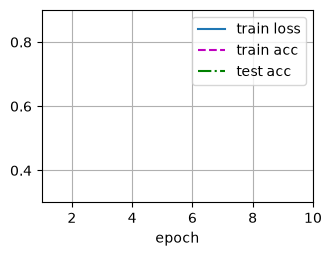

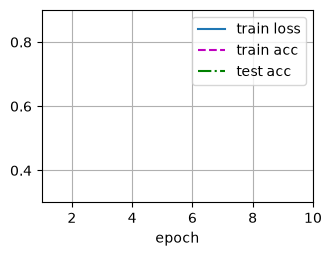

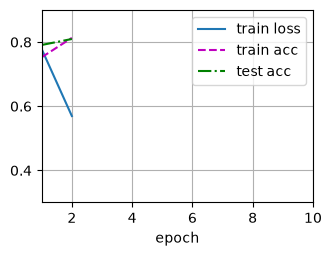

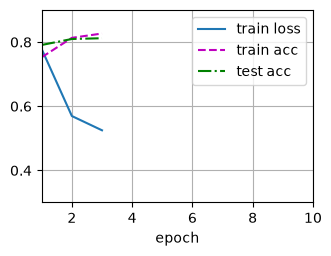

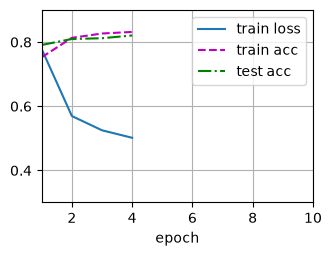

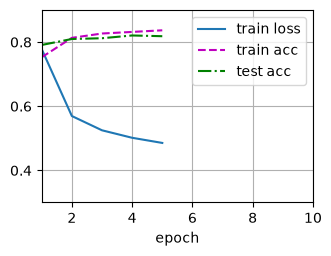

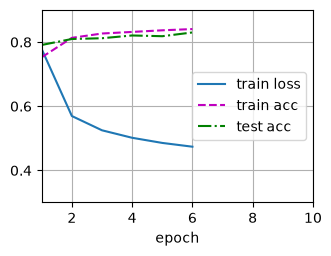

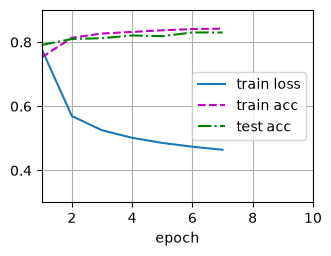

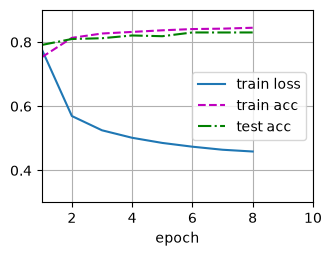

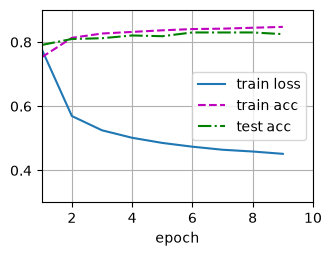

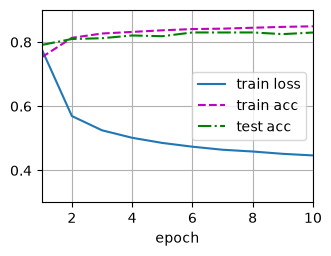

In [23]:
num_epochs=10
train_ch3(net,train_iter,test_iter,cross_entropy,num_epochs,updater)

对图像进行分类预测

C:\Users\24659\AppData\Local\Temp\ipykernel_7520\1905871654.py:47: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24659\AppData\Local\Temp\ipykernel_7520\1905871654.py:47: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24659\AppData\Local\Temp\ipykernel_7520\1905871654.py:47: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\24659\AppData\Local\Temp\ipykernel_7520\1905871654.py:47: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\Users\24659\envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Users\24659\envs\ai\Lib\site-packages\IPython\core\pylabtools.py:158: 

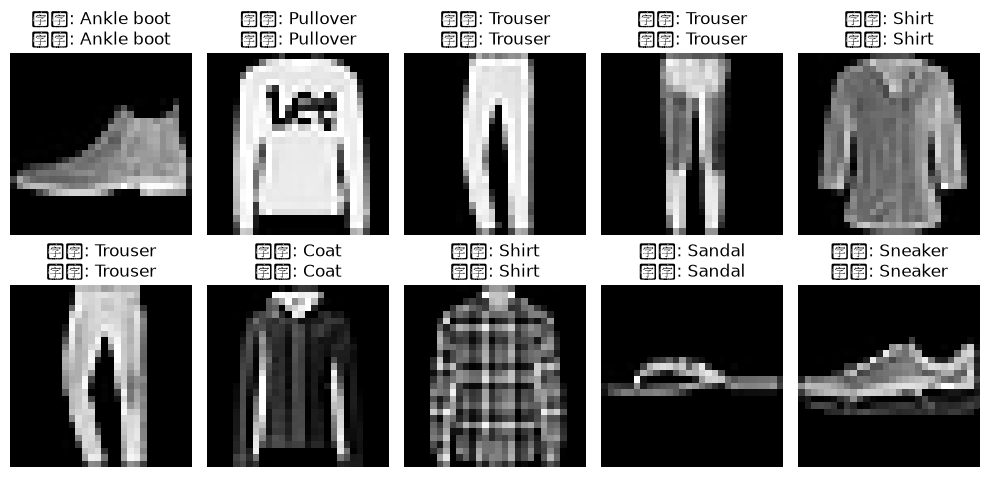

In [25]:
classes = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]


def predict_images(net, test_iter, classes, num=10):
    # 从测试集中取一个 batch
    X, y = next(iter(test_iter))

    # 防止 num 超过当前 batch 的大小
    num = min(num, len(X))

    # 预测阶段不需要计算梯度
    with torch.no_grad():
        y_hat = net(X[:num])

        # 找到每张图片概率最大的类别
        preds = y_hat.argmax(dim=1)

    # 一张图中显示 num 张图片
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    axes = axes.flatten()

    for i in range(num):
        axes[i].imshow(X[i][0], cmap='gray')
        axes[i].axis('off')

        # 预测类别
        pred_class = classes[preds[i].item()]

        # 真实类别
        true_class = classes[y[i].item()]

        axes[i].set_title(
            f'预测: {pred_class}\n真实: {true_class}'
        )

    plt.tight_layout()
    plt.show()


# 调用函数，展示 10 张图片
predict_images(net, test_iter, classes, num=10)